Powerlifting Cohort Shift - Per-Class Standards Over Time

William Le - 06/07/2026

Notebook 1-3 looked at the elite tier as a whole. The natural critique is survivorship: maybe older lifters retired, leaving the remaining population looking younger. This notebook tests that by going per-weight-class. If the per-class winning total has risen across every class over the past decade, that defeats the survivorship critique because it shows the bar moved up regardless of who's still competing.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from powerlifting_cohort.features import add_features, dedupe_lifter_meets
from powerlifting_cohort.bootstrap import class_pctile_diff

Matplotlib is building the font cache; this may take a moment.


Same prep. Drop rows with missing weight class since this whole notebook is per-class.

In [2]:
df = pd.read_pickle("../data/processed/openipf_scoped.pkl")
df = add_features(df)
df = df[df["is_ipf_class"]]
df = dedupe_lifter_meets(df)
df = df.dropna(subset=["TotalKg", "WeightClassKg"])

print(f"{len(df):,} lifter-meets, {df['Name'].nunique():,} lifters")

520,646 lifter-meets, 206,008 lifters


For each (Name, Year, WeightClass), keep the best total of the year. This is the lifter-class-year panel.

In [3]:
ly = df.copy()
idx = ly.groupby(["Name", "Year", "Sex", "WeightClassKg"])["TotalKg"].idxmax()
ly = ly.loc[idx, ["Name", "Year", "Sex", "WeightClassKg", "TotalKg", "Goodlift", "Age"]].reset_index(drop=True)
ly.head()

,Name,Year,Sex,WeightClassKg,TotalKg,Goodlift,Age
0,A Ashwin,2012,M,83,485.0,67.32,16.5
1,A Azize Labidine,2025,M,83,560.0,78.14,NaN
2,A Basma Ahmadi,2025,F,84,300.0,58.11,NaN
3,A Belousov,2019,M,74,250.0,36.81,17.5
4,A Enacer Boudeguezdam,2026,M,74,542.5,79.76,NaN


Per-class winner each year (highest total in the class). Plot the winning total over time for each men's class.

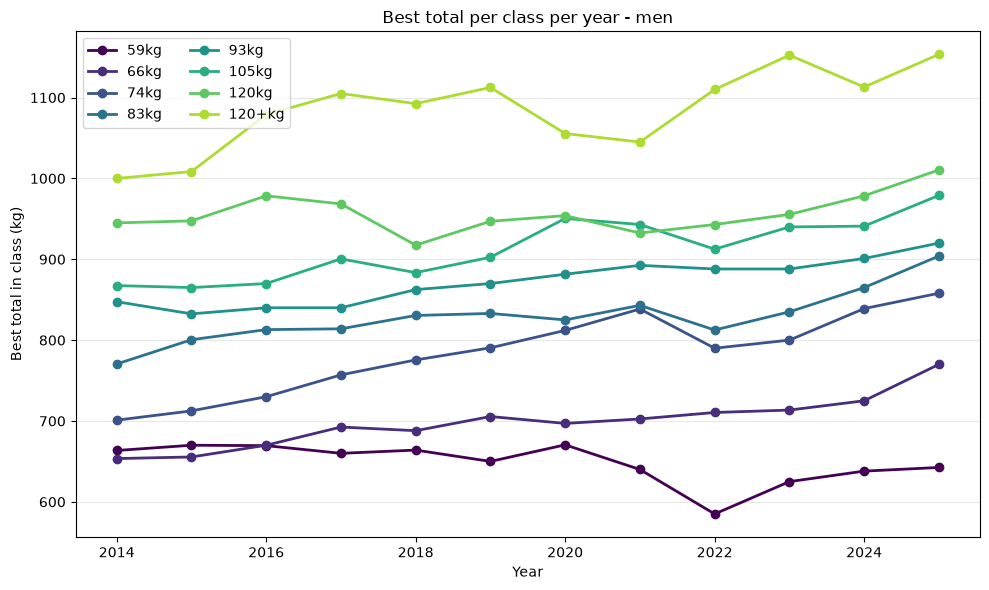

In [4]:
classes_m = ["59","66","74","83","93","105","120","120+"]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis([i/len(classes_m) for i in range(len(classes_m))])

for wc, color in zip(classes_m, colors):
  yearly = (ly[(ly["Sex"]=="M") & (ly["WeightClassKg"]==wc)]
            .groupby("Year")["TotalKg"].max().reset_index())
  yearly = yearly[(yearly["Year"]>=2014) & (yearly["Year"]<=2025)]
  ax.plot(yearly["Year"], yearly["TotalKg"], "o-", color=color, linewidth=2, label=f"{wc}kg")

ax.set_xlabel("Year")
ax.set_ylabel("Best total in class (kg)")
ax.set_title("Best total per class per year - men")
ax.legend(loc="upper left", ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/04_per_class_men.png", dpi=150, bbox_inches="tight")
plt.show()

Same for women's classes.

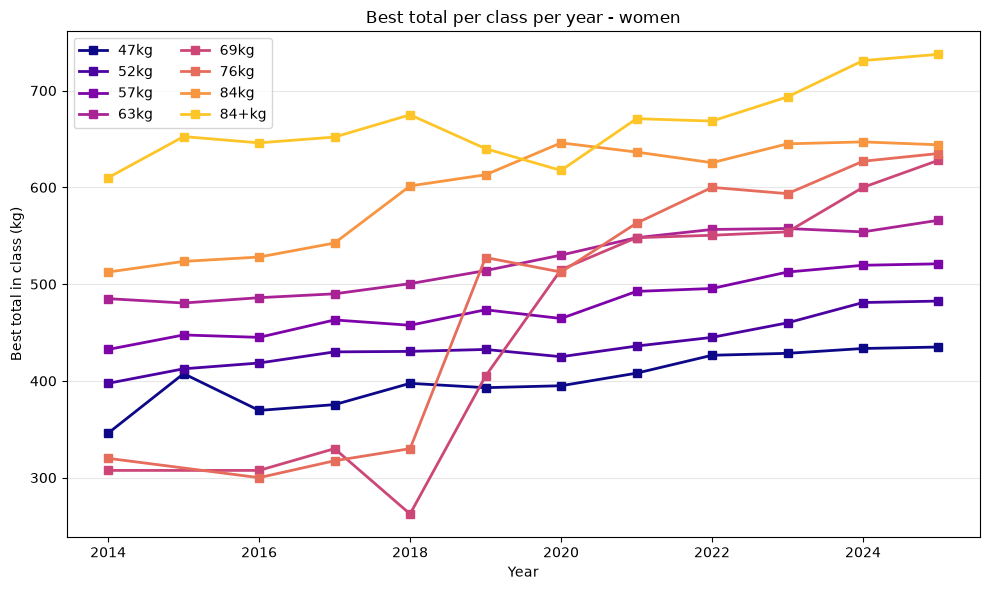

In [5]:
classes_f = ["47","52","57","63","69","76","84","84+"]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma([i/len(classes_f) for i in range(len(classes_f))])

for wc, color in zip(classes_f, colors):
  yearly = (ly[(ly["Sex"]=="F") & (ly["WeightClassKg"]==wc)]
            .groupby("Year")["TotalKg"].max().reset_index())
  yearly = yearly[(yearly["Year"]>=2014) & (yearly["Year"]<=2025)]
  ax.plot(yearly["Year"], yearly["TotalKg"], "s-", color=color, linewidth=2, label=f"{wc}kg")

ax.set_xlabel("Year")
ax.set_ylabel("Best total in class (kg)")
ax.set_title("Best total per class per year - women")
ax.legend(loc="upper left", ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/04_per_class_women.png", dpi=150, bbox_inches="tight")
plt.show()

Per-class winner table for selected years - shows the changing of the guard and the rising standards together.

In [6]:
def winner_per_class(ly, sex, year, classes):
  rows = []
  for wc in classes:
    cl = ly[(ly["Sex"]==sex) & (ly["Year"]==year) & (ly["WeightClassKg"]==wc)]
    if len(cl)==0: continue
    best = cl.nlargest(1, "TotalKg").iloc[0]
    rows.append({
        "Class": f"{wc}kg",
        "Lifter": best["Name"],
        "Age": best["Age"],
        "Total": best["TotalKg"],
        "GL": best["Goodlift"]
    })
  return pd.DataFrame(rows)

print("Men's class winners by year:")
print()
for yr in [2017, 2020, 2023, 2026]:
  print(f"--- {yr} ---")
  print(winner_per_class(ly, "M", yr, classes_m).to_string(index=False))
  print()

Men's class winners by year:

--- 2017 ---
 Class               Lifter  Age  Total     GL
  59kg    Sergey Fedosienko 34.0  660.0 109.78
  66kg        Keith McHoney 31.5  692.5 108.12
  74kg Kjell Egil Bakkelund 28.5  757.0 111.42
  83kg          Brett Gibbs 26.0  814.0 112.78
  93kg        Ashton Rouska 20.0  840.0 111.10
 105kg Krzysztof Wierzbicki 26.0  900.5 113.98
 120kg     Dennis Cornelius 36.5  968.5 112.79
120+kg      Ray Williams #1 30.0 1105.0 109.58

--- 2020 ---
 Class             Lifter  Age  Total     GL
  59kg  Sergey Fedosienko 37.0  670.5 110.95
  66kg Jonathan Garcia #1 32.0  697.0 108.81
  74kg      Taylor Atwood 32.0  812.0 119.44
  83kg       Sean Noriega 24.0  825.0 114.55
  93kg      Ashton Rouska 23.0  881.5 115.84
 105kg      Ashton Rouska 23.0  950.5 120.97
 120kg        Johan Smith 28.0  954.0 110.90
120+kg     Jesus Olivares 22.0 1055.5 109.94

--- 2023 ---
 Class                 Lifter  Age  Total     GL
  59kg          Wascar Carpio 25.5  625.0 103.42
  6

Total kg gained per class between 2017 and the most recent complete year (2025). This is the headline number for the survivorship-defeat argument.

In [7]:
def class_progression(ly, sex, classes, year_start, year_end):
  rows = []
  for wc in classes:
    early = ly[(ly["Sex"]==sex) & (ly["Year"]==year_start) & (ly["WeightClassKg"]==wc)]
    late = ly[(ly["Sex"]==sex) & (ly["Year"]==year_end) & (ly["WeightClassKg"]==wc)]
    if len(early)==0 or len(late)==0: continue
    e = early.nlargest(1, "TotalKg").iloc[0]
    l = late.nlargest(1, "TotalKg").iloc[0]
    rows.append({
        "Class": f"{wc}kg",
        f"{year_start} winner": f"{e['Name']} ({e['TotalKg']:.0f})",
        f"{year_end} winner": f"{l['Name']} ({l['TotalKg']:.0f})",
        "delta_kg": l["TotalKg"] - e["TotalKg"]
    })
  return pd.DataFrame(rows)

print("Men 2017 -> 2026:")
print(class_progression(ly, "M", classes_m, 2017, 2026).to_string(index=False))
print()
print("Women 2017 -> 2025:")
print(class_progression(ly, "F", classes_f, 2017, 2025).to_string(index=False))

Men 2017 -> 2026:
 Class                2017 winner                2026 winner  delta_kg
  59kg    Sergey Fedosienko (660)     Justin Nguyen #1 (670)      10.0
  66kg        Keith McHoney (692) Kjell Egil Bakkelund (782)      89.5
  74kg Kjell Egil Bakkelund (757)    Austin Perkins #1 (892)     134.5
  83kg          Brett Gibbs (814)    Joseph Borenstein (892)      78.5
  93kg        Ashton Rouska (840)      William Ball #2 (930)      90.0
 105kg Krzysztof Wierzbicki (900)   Anthony McNaughton (980)      79.5
 120kg     Dennis Cornelius (968)        Rondel Hunte (1025)      56.5
120+kg     Ray Williams #1 (1105)      Jesus Olivares (1110)       5.0

Women 2017 -> 2025:
Class                2017 winner              2025 winner  delta_kg
 47kg       Heather Connor (376)     Heather Connor (435)      59.5
 52kg          Marisa Inda (430)     Megan-Li Smith (482)      52.5
 57kg    Jennifer Millican (463)         Sara Naldi (521)      58.0
 63kg Jennifer Thompson #1 (490)  Meghan Scanlon #

For the lifters who held class titles in 2017-2020, what happened to them? Pull each year's class winner and check their last meet, current class, and career-best total. Active = meet in past 24 months.

In [8]:
def status_check(ly, df, sex, classes, years_held):
  rows = []
  for wc in classes:
    for yr in years_held:
      cl = ly[(ly["Sex"]==sex) & (ly["Year"]==yr) & (ly["WeightClassKg"]==wc)]
      if len(cl)==0: continue
      winner = cl.nlargest(1, "TotalKg").iloc[0]
      name = winner["Name"]

      lifter_all = df[df["Name"]==name].sort_values("Date")
      last_date = lifter_all["Date"].max()
      last_class = lifter_all.iloc[-1]["WeightClassKg"] if len(lifter_all) else None
      career_best_total = lifter_all["TotalKg"].max()

      cutoff = pd.Timestamp("2024-04-01")
      active = last_date >= cutoff if pd.notna(last_date) else False

      rows.append({
          "OriginalClass": f"{wc}kg",
          "Year": int(yr),
          "Lifter": name,
          "WinningTotal": winner["TotalKg"],
          "CareerBest": career_best_total,
          "LastClass": last_class if pd.notna(last_class) else "-",
          "LastMeet": last_date.strftime("%Y-%m-%d") if pd.notna(last_date) else "-",
          "Active": "yes" if active else "no"
      })
  return pd.DataFrame(rows)

status = status_check(ly, df, "M", classes_m, [2017, 2018, 2019, 2020])
status = status.drop_duplicates(subset=["Lifter", "OriginalClass"])
status = status.sort_values(["OriginalClass", "Year"])
print(status.to_string(index=False))

OriginalClass  Year                 Lifter  WinningTotal  CareerBest LastClass   LastMeet Active
        105kg  2017   Krzysztof Wierzbicki         900.5       900.5        93 2019-09-07     no
        105kg  2018           Rondel Hunte         883.5      1025.0       120 2026-01-24    yes
        105kg  2019            Bryce Lewis         902.5       927.5        93 2023-02-24     no
        105kg  2020          Ashton Rouska         950.5       983.0       120 2026-03-05    yes
       120+kg  2017        Ray Williams #1        1105.0      1112.5      120+ 2024-08-04    yes
       120+kg  2020         Jesus Olivares        1055.5      1153.5      120+ 2026-03-05    yes
        120kg  2017       Dennis Cornelius         968.5      1000.0       120 2021-06-14     no
        120kg  2018            Tony Cliffe         917.5       955.5       120 2024-11-21    yes
        120kg  2020            Johan Smith         954.0       954.0       120 2020-11-07     no
         59kg  2017      Serge

In [9]:
def progression_with_ci(ly, sex, classes, year_a, year_b, n_boot=1000):
  rows = []
  for wc in classes:
    pt, lo, hi = class_pctile_diff(ly, sex, wc, year_a, year_b, pct=95, n_boot=n_boot)
    rows.append({
        "Class": f"{wc}kg",
        f"delta_95th_pct": pt, "lo": lo, "hi": hi
    })
  return pd.DataFrame(rows)

print("Men 2017 -> 2026: change in 95th percentile total per class")
print(progression_with_ci(ly, "M", classes_m, 2017, 2026).to_string(index=False))
print()
print("Women 2017 -> 2025: change in 95th percentile total per class")
print(progression_with_ci(ly, "F", classes_f, 2017, 2025).to_string(index=False))

Men 2017 -> 2026: change in 95th percentile total per class
 Class  delta_95th_pct        lo        hi
  59kg          69.250 45.924375 92.000000
  66kg          74.925 57.500000 90.878125
  74kg          60.000 50.625000 71.515625
  83kg          57.500 47.500000 67.500000
  93kg          47.500 42.299375 60.000000
 105kg          62.500 52.500000 72.500000
 120kg          50.000 30.000000 75.503125
120+kg          32.500  1.493750 72.012500

Women 2017 -> 2025: change in 95th percentile total per class
Class  delta_95th_pct        lo        hi
 47kg          45.500 29.875000 58.534375
 52kg          46.000 35.250000 58.502500
 57kg          45.000 40.000000 55.000000
 63kg          42.500 35.000000 47.500000
 69kg             NaN       NaN       NaN
 76kg             NaN       NaN       NaN
 84kg          60.125 50.995625 74.503125
84+kg          52.500 33.200000 63.762500


Across every men's class the winning total in 2026 was substantially higher than in 2017. The middleweight classes gained the most: 74kg by 134.5kg (Perkins's 891.5 at Sheffield), 93kg by 90kg, 105kg by 79.5kg, and 83kg by 78.5kg. 66kg gained 89.5kg and 59kg gained 10kg. The two heaviest classes gained less, 56.5kg at 120 and 5kg at 120+, consistent with heavyweight powerlifting changing more slowly. Women's classes gained 50 to 92kg across the board.

The youth shift shows up directly in who is winning these classes. Among the 2026 men's class winners, Justin Nguyen took 59kg at 16 (sub-junior), Austin Nikolai took 66kg at 22, Joseph Borenstein took 83kg at 23, and William Ball took 93kg at 20. The 74kg class is the exception and the benchmark: Austin Perkins owns it at 26, having reached the top at 24 as an Open lifter and continued to rise. The heaviest classes are held by lifters in their late 20s (McNaughton 25 at 105, Hunte 30 at 120, Olivares 27 at 120+).

The lifters who held these classes in 2017 to 2020 are mostly still competing. Atwood moved from 74 to 83 kg. Rouska moved from 105 to 120 kg after McNaughton overtook 105. Olivares stayed at 120+ and added weight to his own peak. They were not removed from the data; the bar moved up under them, which is the direct evidence against a pure-selection explanation.